In [3]:
import pandas as pd


df = pd.read_csv("/Users/striker/Pythonprojects/ecommerce_eda_dataset.csv")

df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          3000 non-null   int64  
 1   customer_id       3000 non-null   int64  
 2   age               3000 non-null   int64  
 3   city              3000 non-null   object 
 4   product_category  3000 non-null   object 
 5   payment_method    3000 non-null   object 
 6   order_value       3000 non-null   float64
 7   discount          3000 non-null   float64
 8   delivery_days     3000 non-null   int64  
 9   is_returned       3000 non-null   int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 234.5+ KB


,order_id,customer_id,age,order_value,discount,delivery_days,is_returned
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,1501.488000,41.153000,10117.546793,0.150997,4.937667,0.159667
std,866.169729,295.428914,13.476701,5685.396217,0.086043,2.570730,0.366358
min,1.000000,1000.000000,18.000000,202.350000,0.000000,1.000000,0.000000
25%,750.750000,1242.000000,30.000000,5288.177500,0.080000,3.000000,0.000000
50%,1500.500000,1502.000000,41.000000,10136.060000,0.150000,5.000000,0.000000
75%,2250.250000,1762.250000,53.000000,14936.160000,0.220000,7.000000,0.000000
max,3000.000000,1998.000000,64.000000,19992.790000,0.300000,9.000000,1.000000


In [5]:
#Missing values
df.isnull().sum()

order_id            0
customer_id         0
age                 0
city                0
product_category    0
payment_method      0
order_value         0
discount            0
delivery_days       0
is_returned         0
dtype: int64

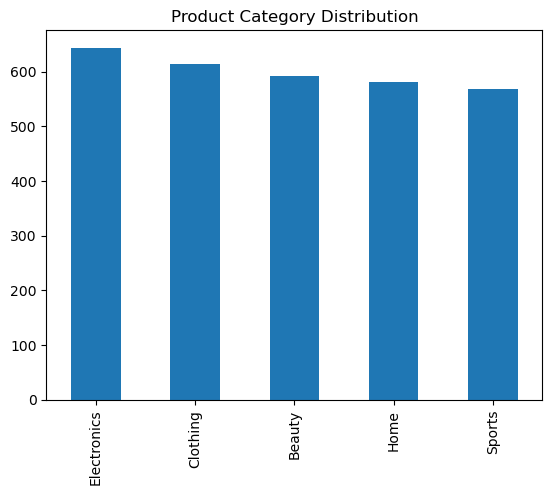

In [6]:
#Univariate analysis
import matplotlib.pyplot as plt

df['product_category'].value_counts().plot(kind='bar')
plt.title("Product Category Distribution")
plt.show()

In [7]:
#Sales analysis
df.groupby('product_category')['order_value'].sum().sort_values(ascending=False)

product_category
Electronics    6383653.14
Clothing       6320311.47
Home           6022593.58
Beauty         5906624.58
Sports         5719457.61
Name: order_value, dtype: float64

In [8]:
#Customer behavior
df.groupby('city')['order_value'].mean()

city
Bangalore    10183.642940
Chennai      10171.082091
Delhi         9937.904886
Hyderabad    10280.470140
Mumbai       10020.532615
Name: order_value, dtype: float64

In [10]:
#Return analysis
df.groupby('product_category')['is_returned'].mean()

product_category
Beauty         0.146959
Clothing       0.154723
Electronics    0.152174
Home           0.175258
Sports         0.170775
Name: is_returned, dtype: float64

In [11]:
#Discount Impact
df[['discount', 'order_value']].corr()

,discount,order_value
discount,1.000000,-0.020295
order_value,-0.020295,1.000000


In [12]:
#Delivery Analysis
df.groupby('delivery_days')['is_returned'].mean()

delivery_days
1    0.184211
2    0.137143
3    0.137931
4    0.161473
5    0.144654
6    0.160763
7    0.134375
8    0.207120
9    0.170807
Name: is_returned, dtype: float64

In [13]:
#Revenue Drivers 
df.groupby(['product_category'])['order_value'].agg(['sum','mean','count'])

,sum,mean,count
product_category,,,
Beauty,5906624.58,9977.406385,592
Clothing,6320311.47,10293.666889,614
Electronics,6383653.14,9912.504876,644
Home,6022593.58,10348.098935,582
Sports,5719457.61,10069.467623,568


In [14]:
#Customer Segmentation
df['spending_segment'] = pd.qcut(df['order_value'], 3, labels=['Low','Medium','High'])
df.groupby('spending_segment')['order_value'].mean()

spending_segment
Low        3549.23700
Medium    10150.25699
High      16653.14639
Name: order_value, dtype: float64

In [15]:
#City-Level Performance
df.groupby('city')['order_value'].agg(['sum','mean','count'])

,sum,mean,count
city,,,
Bangalore,6649918.84,10183.642940,653
Chennai,5838201.12,10171.082091,574
Delhi,6081997.79,9937.904886,612
Hyderabad,5880428.92,10280.470140,572
Mumbai,5902093.71,10020.532615,589


In [16]:
#Return Behavior
df.groupby('product_category')['is_returned'].mean().sort_values(ascending=False)

product_category
Home           0.175258
Sports         0.170775
Clothing       0.154723
Electronics    0.152174
Beauty         0.146959
Name: is_returned, dtype: float64

In [17]:
#Delivery vs Returns
df.groupby('delivery_days')['is_returned'].mean()

delivery_days
1    0.184211
2    0.137143
3    0.137931
4    0.161473
5    0.144654
6    0.160763
7    0.134375
8    0.207120
9    0.170807
Name: is_returned, dtype: float64

In [19]:
#payment order
df.groupby('payment_method')['order_value'].mean()

payment_method
Card          10245.708107
NetBanking    10070.552687
UPI            9913.934058
Wallet        10253.357054
Name: order_value, dtype: float64

In [20]:
#product category and city
df.groupby(['city','product_category'])['order_value'].sum()

city       product_category
Bangalore  Beauty              1279791.24
           Clothing            1407459.34
           Electronics         1459957.59
           Home                1282011.53
           Sports              1220699.14
Chennai    Beauty              1114382.51
           Clothing            1104571.81
           Electronics         1253666.36
           Home                1108007.50
           Sports              1257572.94
Delhi      Beauty              1261916.56
           Clothing            1178116.34
           Electronics         1220727.61
           Home                1396074.12
           Sports              1025163.16
Hyderabad  Beauty              1233052.38
           Clothing            1334655.58
           Electronics         1258838.58
           Home                1057946.34
           Sports               995936.04
Mumbai     Beauty              1017481.89
           Clothing            1295508.40
           Electronics         1190463.00
      